# Music Emotion Recognition using CRNN Regression (PyTorch)
## DEAM Dataset — Predicting Valence & Arousal

This notebook builds a **CRNN (CNN + GRU)** regression model to predict **valence** and **arousal** 
values from audio, using **mel-spectrograms + chroma features** as input.

### Pipeline:
1. Load & merge DEAM dynamic (per-second) annotations
2. Extract mel-spectrograms from audio files
3. Build a CRNN regression model (CNN feature extractor + Bidirectional GRU) in PyTorch
4. Train with MSE loss
5. Evaluate with regression metrics (MSE, MAE, R², CCC)
6. Visualize predictions on the valence-arousal plane


## 1. Setup & Imports

In [25]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("All libraries imported successfully!")


Using device: cuda
PyTorch version: 2.10.0+cu128
All libraries imported successfully!


In [26]:
# Mencari nama folder dataset pertama yang ada di /kaggle/input/
input_folders = os.listdir('/kaggle/input')
if input_folders:
    BASE_DIR = os.path.join('/kaggle/input', input_folders[0])
    print(f"BASE_DIR otomatis: {BASE_DIR}")

BASE_DIR otomatis: /kaggle/input/datasets


## 2. Load DEAM Dynamic Annotations

In [27]:
# === Dataset Paths ===
BASE_DIR = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")

# Path to dynamic (per-second) annotations
DYN_ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                             "annotations averaged per song", "dynamic (per second annotations)")

# --- Load dynamic annotation CSVs ---
arousal_file = os.path.join(DYN_ANNOT_DIR, "arousal.csv")
valence_file = os.path.join(DYN_ANNOT_DIR, "valence.csv")

if os.path.exists(arousal_file) and os.path.exists(valence_file):
    df_arousal = pd.read_csv(arousal_file)
    df_valence = pd.read_csv(valence_file)

    # Set song_id as index
    df_arousal = df_arousal.set_index('song_id')
    df_valence = df_valence.set_index('song_id')

    # Find song_ids present in both files
    common_songs = df_arousal.index.intersection(df_valence.index)

    df_arousal = df_arousal.loc[common_songs]
    df_valence = df_valence.loc[common_songs]

    print("✅ Dynamic annotations loaded successfully!")
    print(f"Total annotated songs (dynamic): {len(common_songs)}")
    display(df_arousal.head(3))
else:
    print("❌ ERROR: Dynamic annotation CSV files not found. Check paths:")
    print(arousal_file)
    print(valence_file)


✅ Dynamic annotations loaded successfully!
Total annotated songs (dynamic): 1802


,sample_15000ms,sample_15500ms,sample_16000ms,sample_16500ms,sample_17000ms,sample_17500ms,sample_18000ms,sample_18500ms,sample_19000ms,sample_19500ms,...,sample_622000ms,sample_622500ms,sample_623000ms,sample_623500ms,sample_624000ms,sample_624500ms,sample_625000ms,sample_625500ms,sample_626000ms,sample_626500ms
song_id,,,,,,,,,,,,,,,,,,,,,
2,-0.109386,-0.114942,-0.116413,-0.118613,-0.126457,-0.133199,-0.136855,-0.144713,-0.138985,-0.137602,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.110846,-0.123973,-0.131103,-0.135956,-0.140775,-0.144664,-0.163118,-0.165218,-0.158858,-0.156783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.222327,0.179446,0.178388,0.184056,0.176042,0.178720,0.176345,0.175793,0.176154,0.176604,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Match Audio Files with Annotations

In [28]:
# Find available audio files
audio_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.mp3') or f.endswith('.wav')]
audio_ids = set()
for f in audio_files:
    try:
        song_id = int(f.split('.')[0])
        audio_ids.add(song_id)
    except ValueError:
        continue

print(f"Total audio files found: {len(audio_ids)}")

# Filter annotations to only include songs with audio
common_audio_songs = list(common_songs.intersection(audio_ids))
df_arousal = df_arousal.loc[common_audio_songs]
df_valence = df_valence.loc[common_audio_songs]

print(f"Annotated songs with audio (dynamic): {len(common_audio_songs)}")

# Convert the dynamic dataframe to numpy arrays for easier indexing later
# Bentuk: (N_songs, T_annotations), misal (1800, 30) untuk detik ke 15-45.
# Kolom biasanya berupa string waktu atau miripnya, kita ambil nilai numerik saja
arousal_array = df_arousal.values
valence_array = df_valence.values

# Pastikan mereka memilki shape yang sama
print(f"Arousal shape: {arousal_array.shape}, Valence shape: {valence_array.shape}")


Total audio files found: 1802
Annotated songs with audio (dynamic): 1802
Arousal shape: (1802, 1224), Valence shape: (1802, 1223)


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 (replacement): Song-level train/val/test split FIRST
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

print("Sample columns:", df_arousal.columns[:10].tolist())

# All songs that have both audio and annotations
all_song_ids = list(common_audio_songs)  # from your existing section 3

# Split song IDs (not windows!) to prevent leakage
train_song_ids, temp_ids = train_test_split(all_song_ids, test_size=0.30, random_state=42)
val_song_ids,   test_song_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)

print(f"Songs  — Train: {len(train_song_ids)} | Val: {len(val_song_ids)} | Test: {len(test_song_ids)}")


Sample columns: ['sample_15000ms', 'sample_15500ms', 'sample_16000ms', 'sample_16500ms', 'sample_17000ms', 'sample_17500ms', 'sample_18000ms', 'sample_18500ms', 'sample_19000ms', 'sample_19500ms']
Songs  — Train: 1261 | Val: 270 | Test: 271


## 4. Extract Mel-Spectrograms from Audio

We extract **2-channel features** (log-mel-spectrogram + chroma) which capture both
timbral and tonal information — important for predicting both arousal and valence.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 (replacement): Window-level feature extraction
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import os
import librosa
from scipy.ndimage import zoom as _scipy_zoom
from tqdm import tqdm

SR          = 22050
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 2048
WINDOW_SEC  = 3      # each training sample is 3 seconds of audio
HOP_SEC     = 1      # windows are extracted every 1 second (dense)
TOTAL_SEC   = 45     # audio is cropped to this length

WIN_SAMPLES  = SR * WINDOW_SEC
WIN_FRAMES   = WIN_SAMPLES // HOP_LENGTH   # ≈ 128 mel-time-frames per window

FEAT_DIR = "deam_windows_cache"
os.makedirs(FEAT_DIR, exist_ok=True)


def load_audio_padded(file_path, sr=SR, total_sec=TOTAL_SEC):
    """Load and centre-crop (or pad) audio to exactly total_sec seconds."""
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target = sr * total_sec
    if len(y) >= target:
        start = (len(y) - target) // 2
        y = y[start:start + target]
    else:
        pad = target - len(y)
        y = np.pad(y, (pad // 2, pad - pad // 2), mode='constant')
    return y


def extract_window_features(y, start_sample, sr=SR):
    """
    Extract a (2, N_MELS, WIN_FRAMES) feature tensor for one window.
    Channel 0: log-mel spectrogram
    Channel 1: chroma — kept at 12 rows, zero-padded to N_MELS
                (avoids the misleading scipy.zoom upsample)
    """
    segment = y[start_sample: start_sample + WIN_SAMPLES]
    if len(segment) < WIN_SAMPLES:
        segment = np.pad(segment, (0, WIN_SAMPLES - len(segment)))

    # Log-mel
    mel = librosa.feature.melspectrogram(
        y=segment, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT)
    log_mel = librosa.power_to_db(mel, ref=np.max)          # (128, WIN_FRAMES)

    # Chroma — 12 rows, zero-padded to N_MELS rows at the bottom
    chroma = librosa.feature.chroma_stft(
        y=segment, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH)  # (12, WIN_FRAMES)
    chroma_padded = np.zeros((N_MELS, chroma.shape[1]), dtype=np.float32)
    chroma_padded[:12, :] = chroma                           # real data in top 12 rows

    # Stack → (2, N_MELS, WIN_FRAMES)
    return np.stack([log_mel, chroma_padded], axis=0).astype(np.float32)


def get_annotation_columns(df):
    """
    Return numeric annotation times (in seconds) from the dataframe columns.
    DEAM dynamic CSVs have columns like 'sample_15000ms' -> 15.0 seconds.
    """
    cols = []
    for c in df.columns:
        if c.startswith('sample_') and c.endswith('ms'):
            ms_str = c.replace('sample_', '').replace('ms', '')
            try:
                sec_val = float(ms_str) / 1000.0
                cols.append((sec_val, c))
            except ValueError:
                pass
        else:
            try:
                cols.append((float(c), c))
            except ValueError:
                pass
    cols.sort()
    return cols   # list of (time_sec, col_name)


# Pre-parse annotation columns once
annot_cols = get_annotation_columns(df_arousal)   # [(15.0, 'sample_15000ms'), ...]
annot_times = np.array([t for t, _ in annot_cols])
annot_names = [n for _, n in annot_cols]

print(f"Annotation seconds: {annot_times[:5]} ... {annot_times[-5:]}")
print(f"Window size: {WINDOW_SEC}s → {WIN_FRAMES} mel-time-frames")

Annotation seconds: [15.  15.5 16.  16.5 17. ] ... [624.5 625.  625.5 626.  626.5]
Window size: 3s → 129 mel-time-frames


## 5. Prepare Targets from Dynamic Annotations

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 (replacement): Build window records for each split
# ─────────────────────────────────────────────────────────────────────────────

def build_window_records(song_ids, df_arousal, df_valence, audio_dir,
                          feat_dir, augment=False):
    """
    For each song, slide a WINDOW_SEC window every HOP_SEC seconds.
    Each window gets the annotation closest to its centre second.

    Returns a list of dicts:
        { 'feat_path': str, 'valence': float, 'arousal': float }
    """
    records = []
    skipped = 0

    for song_id in tqdm(song_ids, desc="Building windows"):
        song_id = int(song_id)

        # Find audio file
        audio_path = None
        for ext in ['.mp3', '.wav']:
            p = os.path.join(audio_dir, f"{song_id}{ext}")
            if os.path.exists(p):
                audio_path = p
                break
        if audio_path is None:
            skipped += 1
            continue

        # Load audio once per song
        try:
            y = load_audio_padded(audio_path)
        except Exception as e:
            print(f"  ⚠  Song {song_id}: {e}")
            skipped += 1
            continue

        # Annotation row for this song
        row_a = df_arousal.loc[song_id]
        row_v = df_valence.loc[song_id]

        # Slide windows
        for win_idx, start_sec in enumerate(
                range(0, TOTAL_SEC - WINDOW_SEC + 1, HOP_SEC)):

            # Centre second of this window
            center_sec = start_sec + WINDOW_SEC / 2.0

            # Find closest annotation column
            col_idx = int(np.argmin(np.abs(annot_times - center_sec)))
            col_name = annot_names[col_idx]

            val_v = row_v[col_name]
            val_a = row_a[col_name]

            # Skip if annotation is NaN
            if np.isnan(val_v) or np.isnan(val_a):
                continue

            # Cache path
            feat_path = os.path.join(feat_dir, f"{song_id}_w{win_idx:03d}.npy")

            if not os.path.exists(feat_path):
                feats = extract_window_features(y, start_sec * SR)
                np.save(feat_path, feats)

            records.append({
                'feat_path': feat_path,
                'valence':   float(val_v),
                'arousal':   float(val_a),
            })

    print(f"  Done. {len(records)} windows from {len(song_ids) - skipped} songs "
          f"({skipped} skipped).")
    return records


train_records = build_window_records(train_song_ids, df_arousal, df_valence,
                                      AUDIO_DIR, FEAT_DIR)
val_records   = build_window_records(val_song_ids,   df_arousal, df_valence,
                                      AUDIO_DIR, FEAT_DIR)
test_records  = build_window_records(test_song_ids,  df_arousal, df_valence,
                                      AUDIO_DIR, FEAT_DIR)

print(f"\nTotal windows — Train: {len(train_records)} | "
      f"Val: {len(val_records)} | Test: {len(test_records)}")

Building windows: 100%|██████████| 1261/1261 [02:33<00:00,  8.22it/s]


  Done. 54223 windows from 1261 songs (0 skipped).


Building windows: 100%|██████████| 270/270 [00:34<00:00,  7.92it/s]


  Done. 11610 windows from 270 songs (0 skipped).


Building windows: 100%|██████████| 271/271 [00:34<00:00,  7.85it/s]

  Done. 11653 windows from 271 songs (0 skipped).

Total windows — Train: 54223 | Val: 11610 | Test: 11653


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5b: Normalise targets on the train split, apply to all
# ─────────────────────────────────────────────────────────────────────────────

train_valence = np.array([r['valence'] for r in train_records])
train_arousal = np.array([r['arousal'] for r in train_records])

val_mean = train_valence.mean();  val_std = train_valence.std() + 1e-8
aro_mean = train_arousal.mean();  aro_std = train_arousal.std() + 1e-8

print(f"Valence  — mean: {val_mean:.4f}  std: {val_std:.4f}")
print(f"Arousal  — mean: {aro_mean:.4f}  std: {aro_std:.4f}")


def normalise_records(records):
    for r in records:
        r['valence'] = (r['valence'] - val_mean) / val_std
        r['arousal'] = (r['arousal'] - aro_mean) / aro_std
    return records

train_records = normalise_records(train_records)
val_records   = normalise_records(val_records)
test_records  = normalise_records(test_records)

Valence  — mean: 0.1024  std: 0.2274
Arousal  — mean: 0.1344  std: 0.2793


## 6. Create Dataset & DataLoaders

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 (replacement): Dataset & DataLoaders
# ─────────────────────────────────────────────────────────────────────────────

import torch
from torch.utils.data import Dataset, DataLoader

class DEAMWindowDataset(Dataset):
    """
    Each sample is one (WINDOW_SEC)-second window of audio
    with a per-second valence/arousal label.
    """

    def __init__(self, records, augment=False):
        self.records = records
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        mel = np.load(r['feat_path']).astype(np.float32)   # (2, 128, WIN_FRAMES)
        mel = torch.from_numpy(mel)

        if self.augment:
            # Time masking
            if np.random.random() > 0.5:
                t = mel.shape[2]
                t_mask = max(1, int(t * 0.10))
                t0 = np.random.randint(0, max(1, t - t_mask))
                mel[:, :, t0:t0 + t_mask] = 0
            # Frequency masking
            if np.random.random() > 0.5:
                f_mask = max(1, int(N_MELS * 0.12))
                f0 = np.random.randint(0, max(1, N_MELS - f_mask))
                mel[:, f0:f0 + f_mask, :] = 0
            # Random gain
            gain = np.random.uniform(0.8, 1.2)
            mel = mel * gain

        target = torch.FloatTensor([r['valence'], r['arousal']])
        return mel, target


BATCH_SIZE = 32   # can go larger since windows are shorter than full songs

train_dataset = DEAMWindowDataset(train_records, augment=True)
val_dataset   = DEAMWindowDataset(val_records,   augment=False)
test_dataset  = DEAMWindowDataset(test_records,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, drop_last=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Sanity check
batch_mel, batch_tgt = next(iter(train_loader))
print(f"Mel shape : {batch_mel.shape}")    # expect (32, 2, 128, ~128)
print(f"Target shape: {batch_tgt.shape}") # expect (32, 2)

Train batches: 1694 | Val: 363 | Test: 365
Mel shape : torch.Size([32, 2, 128, 130])
Target shape: torch.Size([32, 2])


## 7. CRNN Model (CNN + Bidirectional GRU)

**Architecture:**
1. **CNN Backbone** — 4 convolutional blocks extract local time-frequency features  
2. **Bidirectional GRU** — captures long-range temporal dynamics in both directions  
3. **FC Regression Head** — outputs continuous valence & arousal values  

The CNN pools aggressively along the **frequency** axis while preserving the **time** axis,
so the GRU receives a meaningful temporal sequence.

```
Input  (2, 128, T)  \u2190 mel + chroma
  \u2193 CNN Block 1 \u2192 (64,  64, T/2)
  \u2193 CNN Block 2 \u2192 (128, 32, T/4)
  \u2193 CNN Block 3 \u2192 (256, 16, T/4)  \u2190 pool freq only
  \u2193 CNN Block 4 \u2192 (256,  8, T/4)  \u2190 pool freq only
  \u2193 Reshape    \u2192 (T/4, 2048)       \u2190 temporal sequence
  \u2193 BiGRU      \u2192 (T/4, 256)
  \u2193 AvgPool    \u2192 (256)
  \u2193 FC         \u2192 (2)               \u2190 [valence, arousal]
```

In [40]:
class CRNN(nn.Module):
    """
    CRNN for music emotion regression.

    Architecture
    ------------
    CNN backbone  \u2014  extracts local time-frequency features from the
                     2-channel input (log-mel + chroma).
    Bidirectional GRU  \u2014  captures long-range temporal dynamics.
    FC head       \u2014  regresses continuous valence & arousal.
    """

    def __init__(self, in_channels=2, gru_hidden=128, gru_layers=2,
                 dropout=0.3, n_mels=128):
        super(CRNN, self).__init__()

        # ---------- CNN feature extractor ----------
        self.cnn = nn.Sequential(
            # Block 1: (C, 128, T) -> (64, 64, T/2)
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(dropout * 0.5),

            # Block 2: (64, 64, T/2) -> (128, 32, T/4)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Dropout2d(dropout * 0.5),

            # Block 3: (128, 32, T/4) -> (256, 16, T/4)  pool freq only
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(dropout),

            # Block 4: (256, 16, T/4) -> (256, 8, T/4)  pool freq only
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(dropout),
        )

        # After 4 blocks the frequency dimension is n_mels / 16
        freq_after_cnn = n_mels // 16          # 128 / 16 = 8
        gru_input_size = 256 * freq_after_cnn  # 256 * 8 = 2048

        # ---------- Bidirectional GRU ----------
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if gru_layers > 1 else 0
        )

        # ---------- Regression head ----------
        self.fc = nn.Sequential(
            nn.Linear(gru_hidden * 2, 64),   # x2 for bidirectional
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2),                # valence, arousal
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : Tensor  (batch, channels, freq, time)

        Returns
        -------
        Tensor  (batch, 2)  predicted [valence, arousal]
        """
        batch_size = x.size(0)

        # CNN
        x = self.cnn(x)                          # (B, 256, F', T')

        # reshape for GRU: merge channel & freq -> feature dim
        x = x.permute(0, 3, 1, 2)                # (B, T', 256, F')
        x = x.reshape(batch_size, x.size(1), -1) # (B, T', 256*F')

        # GRU
        x, _ = self.gru(x)                       # (B, T', H*2)

        # Global average pooling over time
        x = x.mean(dim=1)                        # (B, H*2)

        # Regression
        x = self.fc(x)                           # (B, 2)
        return x

# --- Instantiate ---
model = CRNN(in_channels=2, gru_hidden=128, gru_layers=2,
             dropout=0.3, n_mels=N_MELS).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"\n{model}")


Total parameters      : 2,947,458
Trainable parameters  : 2,947,458

CRNN(
  (cnn): Sequential(
    (0): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.15, inplace=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.15, inplace=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=(2, 1), stride=(2

In [41]:
class CombinedLoss(nn.Module):
    """
    Loss = α · MSE  +  (1 - α) · (1 - CCC)

    Start with α=0.5 (balanced). Anneal α → 0.0 over training
    to shift fully onto CCC once the model has learned basic scale.
    """

    def __init__(self, alpha: float = 0.5,
                 ccc_weights: list[float] | None = None,
                 eps: float = 1e-8):
        super().__init__()
        self.alpha   = alpha
        self.mse     = nn.MSELoss()
        self.ccc     = CCCLoss(weights=ccc_weights, eps=eps)

    def forward(self, y_pred: torch.Tensor,
                y_true: torch.Tensor) -> tuple[torch.Tensor, dict]:
        mse_term = self.mse(y_pred, y_true)
        ccc_term = self.ccc(y_pred, y_true)
        total    = self.alpha * mse_term + (1.0 - self.alpha) * ccc_term

        # Return component breakdown for logging
        return total, {
            'loss':     total.item(),
            'mse':      mse_term.item(),
            'ccc_loss': ccc_term.item(),
        }

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# CCC loss — drop-in replacement for nn.MSELoss()
# ─────────────────────────────────────────────────────────────────────────────

import torch
import torch.nn as nn


def ccc_loss_single(y_pred: torch.Tensor, y_true: torch.Tensor,
                    eps: float = 1e-8) -> torch.Tensor:
    """
    Concordance Correlation Coefficient loss for a single output dimension.

    Args:
        y_pred: (N,) predicted values
        y_true: (N,) ground-truth values
        eps:    small constant for numerical stability

    Returns:
        Scalar loss = 1 - CCC  ∈ [0, 2]
        (0 = perfect agreement, 2 = perfect disagreement)
    """
    mean_pred = y_pred.mean()
    mean_true = y_true.mean()

    # Variance of each signal
    var_pred = ((y_pred - mean_pred) ** 2).mean()
    var_true = ((y_true - mean_true) ** 2).mean()

    # Covariance (using mean, not sum/N-1, so it matches the CCC definition)
    covariance = ((y_pred - mean_pred) * (y_true - mean_true)).mean()

    ccc = (2.0 * covariance) / (
        var_pred + var_true + (mean_pred - mean_true) ** 2 + eps
    )
    return 1.0 - ccc   # minimise → maximise CCC


class CCCLoss(nn.Module):
    """
    CCC loss averaged over both output dimensions (valence + arousal).

    Args:
        weights:  (2,) per-dimension weights, e.g. [1.5, 1.0] to upweight
                  valence (harder to predict). Defaults to equal weighting.
        eps:      numerical stability constant
    """

    def __init__(self, weights: list[float] | None = None, eps: float = 1e-8):
        super().__init__()
        if weights is None:
            weights = [1.0, 1.0]
        self.register_buffer('weights', torch.tensor(weights, dtype=torch.float32))
        self.eps = eps

    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        """
        Args:
            y_pred: (B, 2)  predicted [valence, arousal]
            y_true: (B, 2)  ground-truth [valence, arousal]

        Returns:
            Weighted mean of (1 - CCC) across both dimensions.
        """
        loss_valence = ccc_loss_single(y_pred[:, 0], y_true[:, 0], self.eps)
        loss_arousal = ccc_loss_single(y_pred[:, 1], y_true[:, 1], self.eps)

        losses = torch.stack([loss_valence, loss_arousal])  # (2,)
        # Keep weights aligned to prediction device/dtype to avoid CPU↔CUDA mismatch.
        weights = self.weights.to(device=y_pred.device, dtype=losses.dtype)
        weighted = (losses * weights) / weights.sum()
        return weighted.sum()

## 8. Helpers: CCC Metric & Evaluation Function

In [45]:
def concordance_correlation_coefficient(y_true, y_pred):
    """Concordance Correlation Coefficient (CCC) \u2014 standard MER metric."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true  = np.var(y_true)
    var_pred  = np.var(y_pred)
    cov       = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * cov) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)
    return ccc


def evaluate(model, dataloader, criterion, device):
    """Run model on *dataloader* and return a metrics dict + arrays."""
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for mel_spec, target in dataloader:
            mel_spec, target = mel_spec.to(device), target.to(device)
            output = model(mel_spec)
            loss, _   = criterion(output, target)
            total_loss += loss.item() * mel_spec.size(0)
            all_preds.append(output.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss    = total_loss / len(dataloader.dataset)
    all_preds   = np.concatenate(all_preds,   axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    metrics = {
        'loss':         avg_loss,
        'valence_mse':  mean_squared_error(all_targets[:, 0], all_preds[:, 0]),
        'arousal_mse':  mean_squared_error(all_targets[:, 1], all_preds[:, 1]),
        'valence_mae':  mean_absolute_error(all_targets[:, 0], all_preds[:, 0]),
        'arousal_mae':  mean_absolute_error(all_targets[:, 1], all_preds[:, 1]),
        'valence_r2':   r2_score(all_targets[:, 0], all_preds[:, 0]),
        'arousal_r2':   r2_score(all_targets[:, 1], all_preds[:, 1]),
        'valence_ccc':  concordance_correlation_coefficient(all_targets[:, 0], all_preds[:, 0]),
        'arousal_ccc':  concordance_correlation_coefficient(all_targets[:, 1], all_preds[:, 1]),
    }
    return metrics, all_preds, all_targets

print("\u2705 Helpers defined.")


✅ Helpers defined.


## 9. Training

- **Loss**: MSE (Mean Squared Error) for regression
- **Optimizer**: AdamW with weight decay
- **Scheduler**: ReduceLROnPlateau to adapt learning rate
- **Gradient clipping**: max norm = 1.0 for GRU stability

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Hyperparameters
# ─────────────────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 60
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-4
ALPHA_START     = 0.5    # initial MSE weight in combined loss
ALPHA_END       = 0.0    # final MSE weight (pure CCC by end of training)
PATIENCE        = 12     # early-stopping patience on val mean CCC
MIN_DELTA       = 1e-4   # minimum CCC improvement to reset patience counter

# ─────────────────────────────────────────────────────────────────────────────
# Instantiate
# ─────────────────────────────────────────────────────────────────────────────
criterion = CombinedLoss(
    alpha=ALPHA_START,
    ccc_weights=[1.5, 1.0],   # upweight valence — harder to learn
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',    # NOTE: mode='max' because we track CCC ↑
    factor=0.5, patience=6)

# ─────────────────────────────────────────────────────────────────────────────
# Training state
# ─────────────────────────────────────────────────────────────────────────────
best_val_ccc    = -float('inf')
patience_count  = 0
train_losses    = []
val_losses      = []
val_ccc_history = []

# ─────────────────────────────────────────────────────────────────────────────
# Training loop
# ─────────────────────────────────────────────────────────────────────────────
for epoch in range(NUM_EPOCHS):

    # ── Anneal alpha linearly: ALPHA_START → ALPHA_END over all epochs ──────
    alpha = ALPHA_START + (ALPHA_END - ALPHA_START) * (epoch / max(NUM_EPOCHS - 1, 1))
    criterion.alpha = alpha

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    epoch_mse  = 0.0
    epoch_ccc_loss = 0.0

    for mel_spec, target in tqdm(train_loader,
                                  desc=f'Epoch {epoch+1}/{NUM_EPOCHS}',
                                  leave=False):
        mel_spec, target = mel_spec.to(device), target.to(device)

        optimizer.zero_grad()
        output           = model(mel_spec)
        loss, breakdown  = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        n = mel_spec.size(0)
        epoch_loss     += breakdown['loss']     * n
        epoch_mse      += breakdown['mse']      * n
        epoch_ccc_loss += breakdown['ccc_loss'] * n

    N = len(train_loader.dataset)
    avg_train_loss = epoch_loss / N
    train_losses.append(avg_train_loss)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_metrics['loss'])

    mean_ccc = (val_metrics['valence_ccc'] + val_metrics['arousal_ccc']) / 2.0
    val_ccc_history.append(mean_ccc)

    # Scheduler steps on mean CCC (higher = better)
    scheduler.step(mean_ccc)

    # ── Checkpoint on best CCC ───────────────────────────────────────────────
    if mean_ccc > best_val_ccc + MIN_DELTA:
        best_val_ccc   = mean_ccc
        patience_count = 0
        torch.save({
            'epoch':      epoch + 1,
            'state_dict': model.state_dict(),
            'val_ccc':    mean_ccc,
            'alpha':      alpha,
        }, 'best_crnn_model.pth')
    else:
        patience_count += 1

    # ── Logging every 5 epochs ───────────────────────────────────────────────
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}  [α={alpha:.2f}]")
        print(f"  Train  — loss: {avg_train_loss:.4f}  "
              f"mse: {epoch_mse/N:.4f}  ccc_loss: {epoch_ccc_loss/N:.4f}")
        print(f"  Val    — Valence CCC: {val_metrics['valence_ccc']:.4f}  "
              f"Arousal CCC: {val_metrics['arousal_ccc']:.4f}  "
              f"Mean CCC: {mean_ccc:.4f}")
        print(f"  Patience: {patience_count}/{PATIENCE}")

    # ── Early stopping ───────────────────────────────────────────────────────
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. "
              f"Best val mean CCC: {best_val_ccc:.4f}")
        break

print(f"\nTraining complete. Best val mean CCC: {best_val_ccc:.4f}")


Epoch 1/60  [α=0.50]
  Train  — loss: 0.5460  mse: 0.6478  ccc_loss: 0.4442
  Val    — Valence CCC: 0.5441  Arousal CCC: 0.7514  Mean CCC: 0.6478
  Patience: 0/12



Epoch 5/60  [α=0.47]
  Train  — loss: 0.3896  mse: 0.4824  ccc_loss: 0.3085
  Val    — Valence CCC: 0.5799  Arousal CCC: 0.7841  Mean CCC: 0.6820
  Patience: 0/12



Epoch 10/60  [α=0.42]
  Train  — loss: 0.3123  mse: 0.4020  ccc_loss: 0.2464
  Val    — Valence CCC: 0.5814  Arousal CCC: 0.7832  Mean CCC: 0.6823
  Patience: 4/12



Epoch 15/60  [α=0.38]
  Train  — loss: 0.2380  mse: 0.3177  ccc_loss: 0.1888
  Val    — Valence CCC: 0.5801  Arousal CCC: 0.7630  Mean CCC: 0.6715
  Patience: 9/12



Early stopping at epoch 18. Best val mean CCC: 0.6948

Training complete. Best val mean CCC: 0.6948


## 10. Evaluate on Test Set

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 (replacement): Denormalise predictions before computing metrics
# ─────────────────────────────────────────────────────────────────────────────

# After test evaluation, invert the z-score to get interpretable numbers
test_metrics, test_preds, test_targets_arr = evaluate(
    model, test_loader, criterion, device)

# Denormalise
test_preds_orig    = test_preds.copy()
test_targets_orig  = test_targets_arr.copy()

test_preds_orig[:, 0]   = test_preds[:, 0]   * val_std + val_mean
test_preds_orig[:, 1]   = test_preds[:, 1]   * aro_std + aro_mean
test_targets_orig[:, 0] = test_targets_arr[:, 0] * val_std + val_mean
test_targets_orig[:, 1] = test_targets_arr[:, 1] * aro_std + aro_mean

# Use denormalised arrays for scatter plots and VA-plane visualisation

## 11. Visualize Training History & Predictions

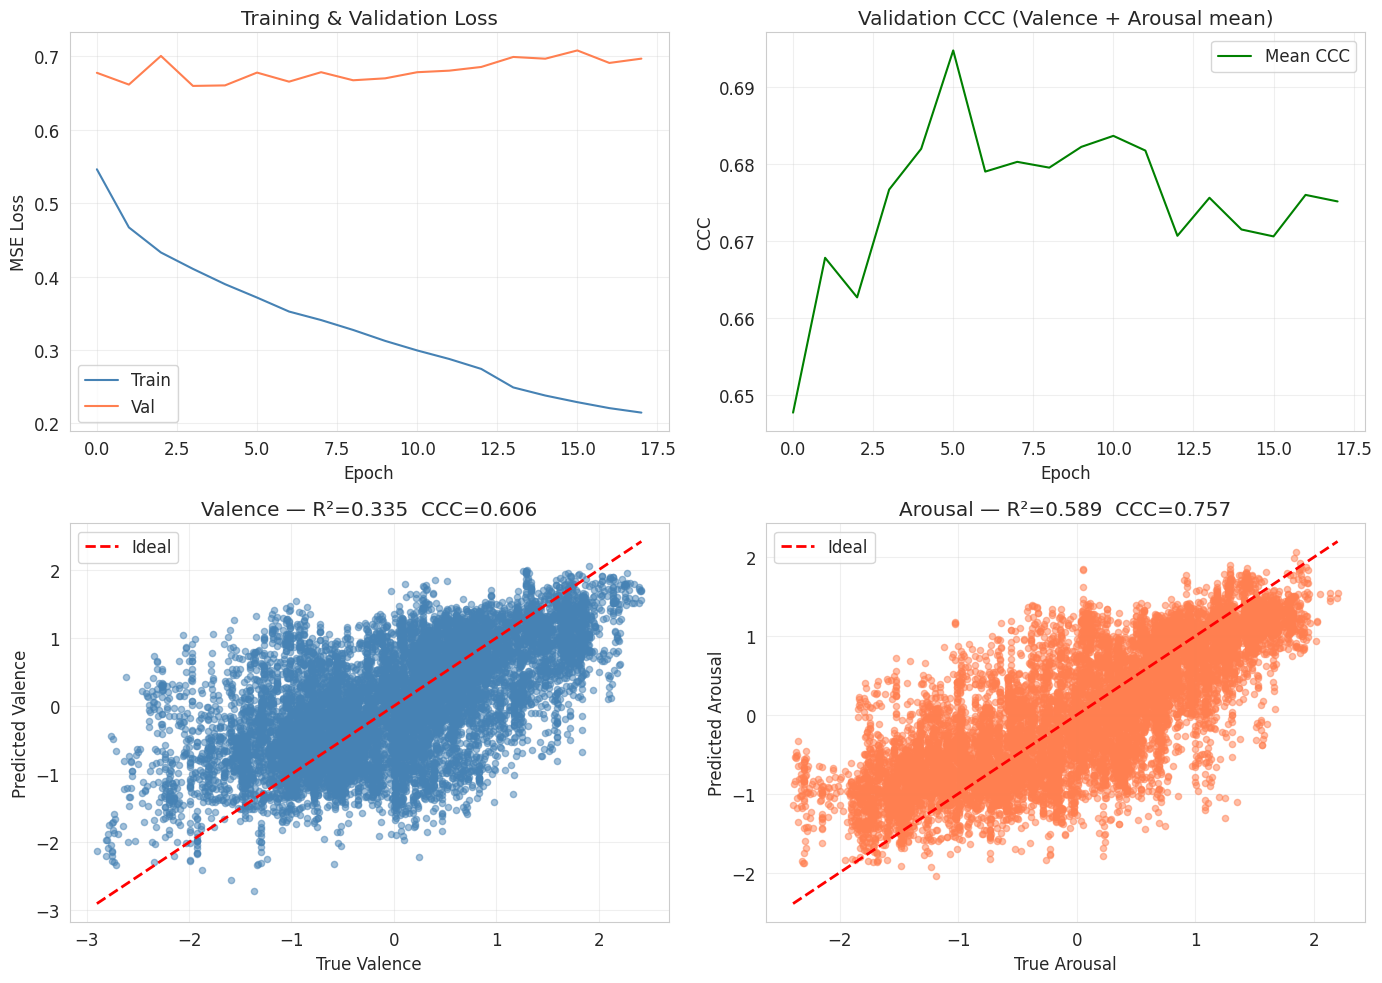

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 \u2014 Loss curves
axes[0, 0].plot(train_losses, label='Train', color='steelblue')
axes[0, 0].plot(val_losses,   label='Val',   color='coral')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2 \u2014 CCC over epochs
axes[0, 1].plot(val_ccc_history, label='Mean CCC', color='green')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('CCC')
axes[0, 1].set_title('Validation CCC (Valence + Arousal mean)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3 \u2014 Valence scatter
axes[1, 0].scatter(test_targets_arr[:, 0], test_preds[:, 0],
                   alpha=0.5, s=20, color='steelblue')
lo = min(test_targets_arr[:, 0].min(), test_preds[:, 0].min())
hi = max(test_targets_arr[:, 0].max(), test_preds[:, 0].max())
axes[1, 0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal')
axes[1, 0].set_xlabel('True Valence'); axes[1, 0].set_ylabel('Predicted Valence')
axes[1, 0].set_title(f'Valence \u2014 R\u00b2={test_metrics["valence_r2"]:.3f}  '
                      f'CCC={test_metrics["valence_ccc"]:.3f}')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 4 \u2014 Arousal scatter
axes[1, 1].scatter(test_targets_arr[:, 1], test_preds[:, 1],
                   alpha=0.5, s=20, color='coral')
lo = min(test_targets_arr[:, 1].min(), test_preds[:, 1].min())
hi = max(test_targets_arr[:, 1].max(), test_preds[:, 1].max())
axes[1, 1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal')
axes[1, 1].set_xlabel('True Arousal'); axes[1, 1].set_ylabel('Predicted Arousal')
axes[1, 1].set_title(f'Arousal \u2014 R\u00b2={test_metrics["arousal_r2"]:.3f}  '
                      f'CCC={test_metrics["arousal_ccc"]:.3f}')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


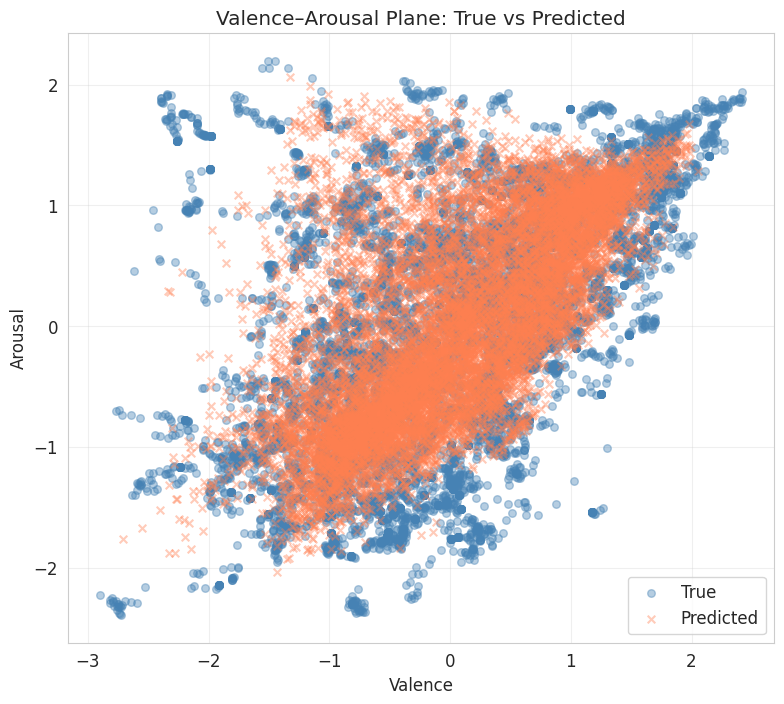

In [49]:
# --- Valence-Arousal plane ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(test_targets_arr[:, 0], test_targets_arr[:, 1],
           alpha=0.4, s=30, label='True', color='steelblue')
ax.scatter(test_preds[:, 0], test_preds[:, 1],
           alpha=0.4, s=30, label='Predicted', color='coral', marker='x')
ax.set_xlabel('Valence'); ax.set_ylabel('Arousal')
ax.set_title('Valence\u2013Arousal Plane: True vs Predicted')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
